<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/fertilizer-scheduling-model/FerilizerSchedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

Cleaning Data, Preprocessing data and feature engineering for Fertilizer dataset.

In [137]:
#fertilizer dataset
fert = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Fertilizer_History.csv', header=None)
fert.columns = ["Division", "Field", "Area", "Type", "Date", "Amount", "Block", "Extra"]
fert = fert.drop(columns=["Extra"]).dropna(how='all')

fert['Division'] = fert['Division'].ffill()
fert = fert[fert['Field'].notna() & (fert['Field'] != 0) & (fert['Field'] != '-') & (fert['Field'] != 'Field')]
fert = fert[fert['Division'] != 'Division']

fert['Area']   = pd.to_numeric(fert['Area'],   errors='coerce')
fert['Amount'] = pd.to_numeric(fert['Amount'], errors='coerce')
fert = fert.dropna(subset=['Area','Amount'])
fert['Date'] = fert['Date'].astype(str).str.replace('Sept', 'Sep', regex=False)
fert['Date'] = pd.to_datetime(fert['Date'], format='%d-%b-%y', errors='coerce')
fert = fert.dropna(subset=['Date'])
fert = fert[fert['Date'].dt.year > 2000]

fert['Month'] = fert['Date'].dt.strftime('%B')

#Feature Engineer
fert['Fertilizer_per_area'] = fert['Amount'] / fert['Area']
fert = fert.sort_values(by=['Division','Field','Date']).reset_index(drop=True)

print("Fert shape:", fert.shape)
print(fert[['Division','Field','Date','Amount']].head())

Fert shape: (65, 9)
  Division Field       Date  Amount
0      AGO    3A 2023-02-12    30.0
1      AGO    3B 2023-08-18    24.0
2      AGO    4A 2024-08-31    11.0
3      AGO    9G 2025-02-02     6.0
4      AGO    9H 2024-03-21    16.0


Cleaning Data, Preprocessing data and feature engineering for the yeild dataset.

In [138]:
#yeild dataset
yield_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Block_Metadata.csv', header=None)
yield_df = yield_df.dropna(how='all').reset_index(drop=True)
yield_df = yield_df.iloc[4:].reset_index(drop=True)  # skip header rows

yield_df.columns = [
    'Division', 'Asst_Manager', 'Field', 'Area', 'Type',
    'Planting_Year', 'Last_Pruned', 'Age_Months'
] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]

#Clean numeric columns
numeric_cols = ['Area','Age_Months'] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]
for col in numeric_cols:
    yield_df[col] = pd.to_numeric(yield_df[col].astype(str).str.replace(',',''), errors='coerce')
yield_df[numeric_cols] = yield_df[numeric_cols].fillna(yield_df[numeric_cols].median())
yield_df['Division']    = yield_df['Division'].ffill()
yield_df['Field']       = yield_df['Field'].ffill()
yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)

#Feature engineering
yield_df['Yield_per_ha']         = yield_df['Year_1'] / yield_df['Area']
last_5_cols                       = [col for col in yield_df.columns if 'Year_' in col][:5]
yield_df['Avg_Yield_Last5Y']     = yield_df[last_5_cols].mean(axis=1)
yield_df['Yield_Trend']          = yield_df['Year_1'] - yield_df['Avg_Yield_Last5Y']  # positive = improving
yield_df['Months_Since_Pruning'] = yield_df['Age_Months'] - ((pd.to_datetime('2025-09-01') - yield_df['Last_Pruned']).dt.days/30)
yield_df['Months_Since_Pruning'] = yield_df['Months_Since_Pruning'].fillna(yield_df['Months_Since_Pruning'].median())

yield_features = yield_df[['Division','Field','Area','Age_Months','Yield_per_ha','Avg_Yield_Last5Y','Yield_Trend','Months_Since_Pruning']]

/tmp/ipykernel_202/3712849259.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)


Cleaning Data, Preprocessing data and feature engineering for climate dataset.

In [139]:
#Climate dataset
climate = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Climate_Data.csv', header=None)
climate = climate.dropna(how='all').reset_index(drop=True)

months = ['January','February','March','April','May','June','July','August','September','October','November','December']
climate = climate[climate[0].str.strip().isin(months)].reset_index(drop=True)

n_cols = climate.shape[1]
columns = ['Month']
num_years = (n_cols - 1)//2
for i in range(num_years):
    columns += [f'Wetdays_Year_{i+1}', f'Rainfall_Year_{i+1}']
if len(columns) != n_cols:
    columns += [f'Extra_{i}' for i in range(len(columns), n_cols)]
climate.columns = columns

# Clean numeric
for col in climate.columns[1:]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(',','').str.replace('-','').str.strip(), errors='coerce')
non_empty_cols = [c for c in climate.columns if climate[c].notna().sum() > 0 or c=='Month']
climate = climate[non_empty_cols]

rainfall_cols = [c for c in climate.columns if 'Rainfall' in c]
wetdays_cols = [c for c in climate.columns if 'Wetdays' in c]

climate['Rainfall_Mean'] = climate[rainfall_cols].mean(axis=1)
climate['Rainfall_Max'] = climate[rainfall_cols].max(axis=1)
climate['Rainfall_Min'] = climate[rainfall_cols].min(axis=1)
climate['Wetdays_Mean'] = climate[wetdays_cols].mean(axis=1)

def compute_trend(row):
    y = row[rainfall_cols].values.astype(float)
    valid_idx = ~np.isnan(y)
    if valid_idx.sum()<2:
        return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x[valid_idx], y[valid_idx])
    return slope

climate['Rainfall_Trend'] = climate.apply(compute_trend, axis=1)

Clean, pre-process and fature engineer plucking round dataset

In [140]:
# Plucking rounds dataset
today = pd.Timestamp.today().normalize()

df_pluck = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Last_10_Year_Data_-_PLUCKING_ROUNDS_-AS_AT_JUNE-25.csv', header=None)
df_pluck.columns = ['Field','Type','Extent','Rounds_2526','Rounds_2425','Rounds_2324']

division_map = {
    'AGROYA DIVISION': 'AGO', 'LOWER DANDUKELLEWA DIVISION': 'LDK',
    'LOWER VELLAI OYA DIVISION': 'LVO', 'UPPER DANDUKELLEWA DIVISION': 'UDK',
    'UPPER VELLAI OYA DIVISION': 'UVO'
}
df_pluck['Division'] = df_pluck['Field'].map(division_map).ffill()

pluck = df_pluck[~df_pluck['Field'].astype(str).str.contains(
    'Division|Estate|PLUCKING|Field|Type', na=True)].copy()
pluck = pluck[pluck['Field'].notna()].copy()

#Convert to numeric
for c in ['Rounds_2526','Rounds_2425','Rounds_2324','Extent']:
    pluck[c] = pd.to_numeric(pluck[c].astype(str).str.strip().replace('-',''), errors='coerce')
pluck['Field'] = pluck['Field'].astype(str).str.strip()

#Feature engineering
pluck['Rounds_Trend'] = pluck['Rounds_2425'] - pluck['Rounds_2324']
pluck['Rounds_Pct_Change'] = ((pluck['Rounds_2425'] - pluck['Rounds_2324']) / pluck['Rounds_2324'] * 100).round(1)
pluck['Rounds_Mean'] = pluck[['Rounds_2324','Rounds_2425']].mean(axis=1)

print("Plucking rounds shape:", pluck.shape)
print(pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change']].head(10))

Plucking rounds shape: (70, 10)
   Division                        Field  Rounds_2324  Rounds_2425  \
4       AGO              AGROYA DIVISION          NaN          NaN   
5       AGO                           3A         29.0         29.0   
6       AGO                           3B         22.0         31.0   
7       AGO                           4A         30.0         21.0   
8       AGO                           9G         30.0         24.0   
9       AGO                           9H         27.0         30.0   
10      AGO                           9I         34.0         28.0   
12      LDK  LOWER DANDUKELLEWA DIVISION          NaN          NaN   
13      LDK                           44         19.0         29.0   
14      LDK                           45         32.0         30.0   

    Rounds_Trend  Rounds_Pct_Change  
4            NaN                NaN  
5            0.0                0.0  
6            9.0               40.9  
7           -9.0              -30.0  
8      

Merging the datasets


In [141]:
merged_df = pd.merge(fert, yield_features, on=['Division','Field'], how='left')
merged_df = pd.merge(merged_df, climate[['Month','Rainfall_Mean','Wetdays_Mean']], on='Month', how='left')
merged_df = pd.merge(merged_df, pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change','Rounds_Mean','Extent']], on=['Division','Field'], how='left')

#Using median to impute missing values
num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

print("Final Merged Dataset:")
print(merged_df.head())
print("\nShape:", merged_df.shape)
print("\nColumns:", merged_df.columns.tolist())

Final Merged Dataset:
  Division Field  Area_x Type       Date  Amount  Block     Month  \
0      AGO    3A     5.0   VP 2023-02-12    30.0    NaN  February   
1      AGO    3B     4.5   VP 2023-08-18    24.0    NaN    August   
2      AGO    4A     4.0   VP 2024-08-31    11.0    NaN    August   
3      AGO    9G     4.0   VP 2025-02-02     6.0    NaN  February   
4      AGO    9H     4.0   VP 2024-03-21    16.0    NaN     March   

   Fertilizer_per_area  Area_y  ...  Yield_Trend  Months_Since_Pruning  \
0             6.000000     5.0  ...       -322.4             -0.066667   
1             5.333333     4.5  ...       -298.8              0.166667   
2             2.750000     4.0  ...       -328.8             -0.200000   
3             1.500000     4.0  ...       -553.6             -0.033333   
4             4.000000     4.0  ...       -151.4              0.366667   

   Rainfall_Mean  Wetdays_Mean  Rounds_2324  Rounds_2425  Rounds_Trend  \
0      96.000000      6.142857         29.0 

Performing Exploratory data analysis on the merged dataset

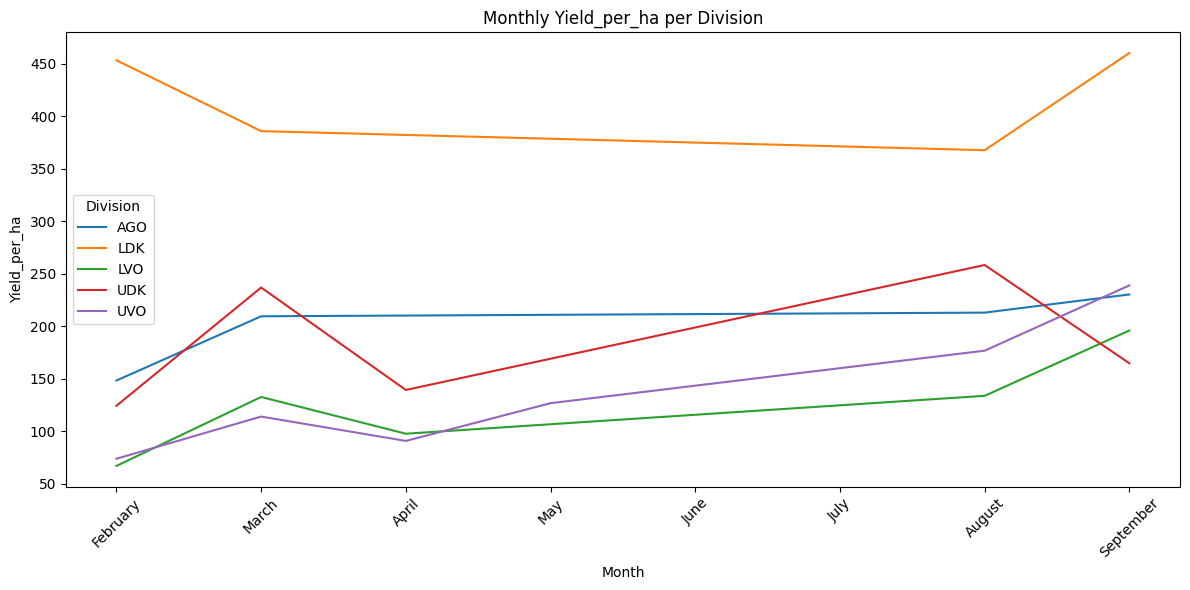

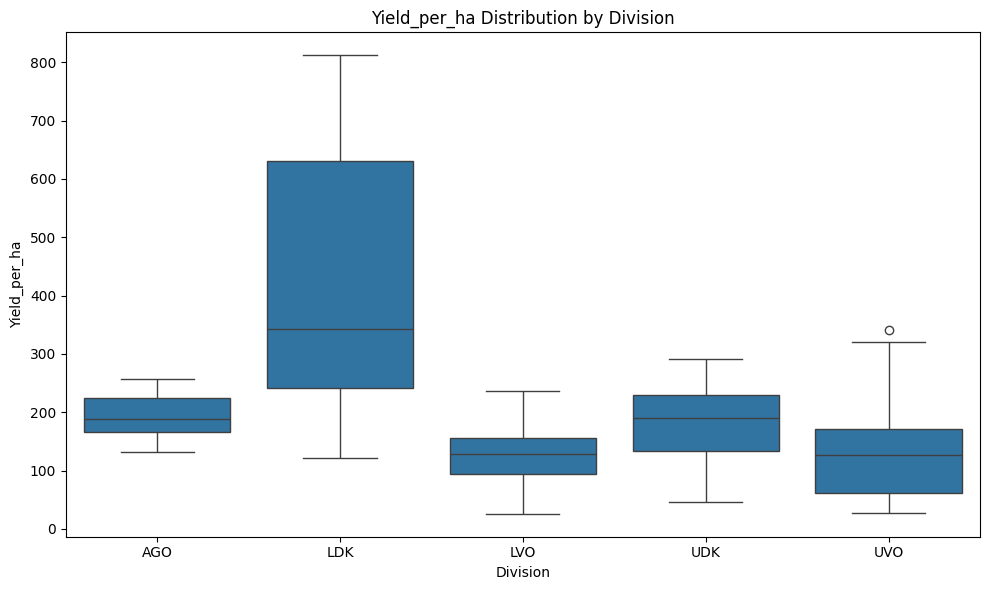

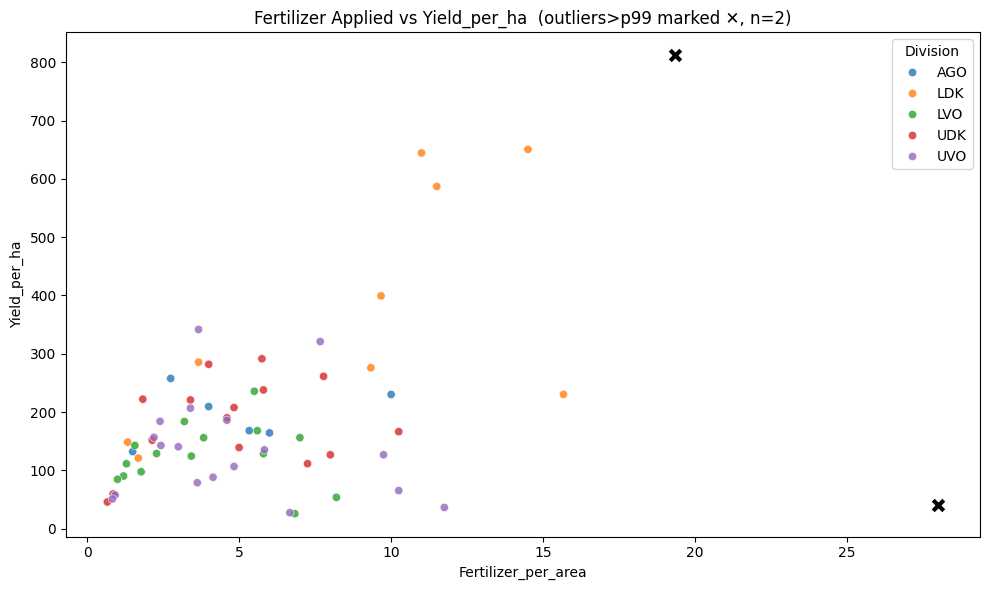


Top correlated numeric features with Yield_per_ha:
 Avg_Yield_Last5Y       0.678948
Area_x                 0.609186
Rounds_2425            0.531675
Rounds_Mean            0.439239
Rounds_Trend           0.419709
Fertilizer_per_area    0.408427
Age_Months             0.254738
Yield_Trend            0.183680
Wetdays_Mean           0.176579
Rainfall_Mean          0.159172
Name: Yield_per_ha, dtype: float64


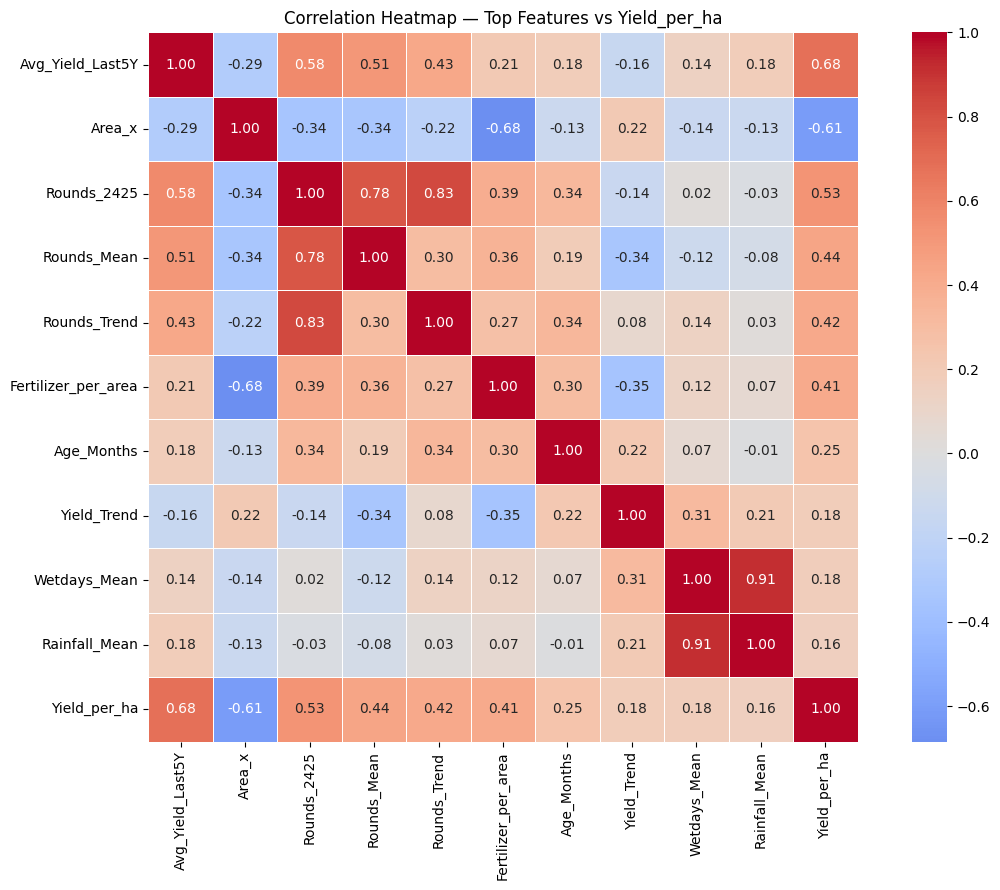

In [142]:
merged_df = merged_df.drop(columns=['Area_y','Extent','Rounds_3Y_Mean','Yield_x_Round','AmountPerHa','Rounds_Pct_Change'], errors='ignore')
df = merged_df.copy()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Lineplot
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', errorbar=None)
plt.title("Monthly Yield_per_ha per Division")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Division', y='Yield_per_ha')
plt.title("Yield_per_ha Distribution by Division")
plt.tight_layout()
plt.show()

# Scatterplot to see outliers
p99_fert  = df['Fertilizer_per_area'].quantile(0.99)
p99_yield = df['Yield_per_ha'].quantile(0.99)
df_main    = df[(df['Fertilizer_per_area'] <= p99_fert) & (df['Yield_per_ha'] <= p99_yield)]
df_outlier = df[(df['Fertilizer_per_area'] > p99_fert)  | (df['Yield_per_ha'] > p99_yield)]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_main,x='Fertilizer_per_area', y='Yield_per_ha', hue='Division', alpha=0.8)
sns.scatterplot(data=df_outlier, x='Fertilizer_per_area', y='Yield_per_ha', marker='X', s=120, color='black', label='Outlier', legend=False)
plt.title(f"Fertilizer Applied vs Yield_per_ha  (outliers>p99 marked ✕, n={len(df_outlier)})")
plt.tight_layout()
plt.show()

# Correlation heatmap with top features
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
top_corr = corr_matrix['Yield_per_ha'].abs().sort_values(ascending=False)[1:11]
print("\nTop correlated numeric features with Yield_per_ha:\n", top_corr)

top_features = top_corr.index.tolist() + ['Yield_per_ha']
plt.figure(figsize=(12,9))
sns.heatmap(
    df[top_features].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5
)
plt.title("Correlation Heatmap — Top Features vs Yield_per_ha")
plt.tight_layout()
plt.show()

In [149]:
#Predicting fertilizer amount (kg/ha)
merged_df['AmountPerHa']    = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc']   = LabelEncoder().fit_transform(merged_df['Division'])
merged_df['Yield_x_Round']  = merged_df['Yield_per_ha'] * merged_df['Rounds_Mean']
merged_df['Age_sq']         = merged_df['Age_Months'] ** 2
merged_df['Rounds_3Y_Mean'] = merged_df[['Rounds_2324','Rounds_2425']].mean(axis=1)

feature_cols = [
    'Avg_Yield_Last5Y', 'Yield_Trend', 'Yield_per_ha', 'Months_Since_Pruning',
    'Rainfall_Mean', 'Wetdays_Mean', 'Division_enc',
    'Age_Months', 'Age_sq', 'Rounds_2324', 'Rounds_2425', 'Rounds_Trend',
    'Rounds_Mean', 'Rounds_3Y_Mean', 'Yield_x_Round'
]

X = merged_df[feature_cols]
y = merged_df['AmountPerHa']

X_s, y_s = shuffle(X, y, random_state=42)
split_idx   = int(len(X_s) * 0.8)
X_train_raw = X_s.iloc[:split_idx]
X_test_raw  = X_s.iloc[split_idx:]

train_median = X_train_raw.median()
X_train = X_train_raw.fillna(train_median)
X_test  = X_test_raw.fillna(train_median)
y_train = y_s.iloc[:split_idx]
y_test  = y_s.iloc[split_idx:]

model = RandomForestRegressor(n_estimators=500,
                              max_depth=6,
                              min_samples_leaf=2,
                              max_features='sqrt',
                              random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2  = r2_score(y_test, y_pred)

print("Model 1 Performance — Fertilizer Amount (kg/ha)")
print(f"MAE        : {mean_absolute_error(y_test, y_pred):.2f} kg/ha")
print(f"Train R²   : {train_r2:.3f}")
print(f"Test  R²   : {test_r2:.3f}")
print(f"Overfit gap: {train_r2 - test_r2:.3f}")

#Feature importance
X_full = X.fillna(train_median)
model.fit(X_full, y)
feature_importance = pd.Series(
    model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("\nTop 10 Important Features:")
print(feature_importance.head(10).round(3))

X_test_amt_eval = X_test.copy()
y_test_amt_eval = y_test.copy()
y_pred_amt_eval = y_pred.copy()

Model 1 Performance — Fertilizer Amount (kg/ha)
MAE        : 1.91 kg/ha
Train R²   : 0.693
Test  R²   : 0.674
Overfit gap: 0.019

Top 10 Important Features:
Yield_x_Round           0.121
Rounds_2425             0.112
Yield_per_ha            0.109
Age_Months              0.095
Age_sq                  0.094
Rounds_Mean             0.090
Avg_Yield_Last5Y        0.086
Rounds_3Y_Mean          0.076
Months_Since_Pruning    0.056
Yield_Trend             0.051
dtype: float64


In [150]:
# Model 2: Predict Days Since Last Fertilizer Application
today = pd.Timestamp.today().normalize()
merged_df['Days_Since_Application'] = (today - merged_df['Date']).dt.days
merged_df['AmountPerHa']  = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc'] = LabelEncoder().fit_transform(merged_df['Division'])

feature_cols_days = [
    'Rounds_2324', 'Rounds_Trend', 'Rounds_Mean', 'AmountPerHa', 'Division_enc',
    'Age_Months', 'Avg_Yield_Last5Y', 'Rainfall_Mean', 'Wetdays_Mean'
]

X_d = merged_df[feature_cols_days].fillna(merged_df[feature_cols_days].median())
y_d = merged_df['Days_Since_Application']

X_ds, y_ds = shuffle(X_d, y_d, random_state=42)
X_ds = X_ds.reset_index(drop=True)
y_ds = y_ds.reset_index(drop=True)

split_idx   = int(len(X_ds) * 0.8)
X_train_raw = X_ds.iloc[:split_idx]
X_test_raw  = X_ds.iloc[split_idx:]

train_median_days = X_train_raw.median()
X_train_d = X_train_raw.fillna(train_median_days)
X_test_d  = X_test_raw.fillna(train_median_days)
y_train_d = y_ds.iloc[:split_idx]
y_test_d  = y_ds.iloc[split_idx:]

model_days = RandomForestRegressor(n_estimators=300,
                                   max_depth=5,
                                   min_samples_leaf=3,
                                   random_state=42)
model_days.fit(X_train_d, y_train_d)
y_pred_d = model_days.predict(X_test_d)

train_r2 = r2_score(y_train_d, model_days.predict(X_train_d))
test_r2  = r2_score(y_test_d, y_pred_d)

print("Model 2 Performance (Days Since Last Fertilizer Application)")
print(f"MAE : {mean_absolute_error(y_test_d, y_pred_d):.0f} days")
print(f"Train r^2: {train_r2:.3f}")
print(f"Test r^2: {test_r2:.3f}")
print(f"Overfit gap: {train_r2 - test_r2:.3f}  (acceptable if < 0.15)")

fi = pd.Series(model_days.feature_importances_, index=feature_cols_days).sort_values(ascending=False)
print("\nTop Features:")
print(fi.round(3))

X_d_full = X_d.fillna(train_median_days)
model_days.fit(X_d_full, y_d)

X_test_dys_eval = X_test_d.copy()
y_test_dys_eval = y_test_d.copy()
y_pred_dys_eval = y_pred_d.copy()

Model 2 Performance (Days Since Last Fertilizer Application)
MAE : 110 days
Train r^2: 0.948
Test r^2: 0.857
Overfit gap: 0.092  (acceptable if < 0.15)

Top Features:
AmountPerHa         0.701
Age_Months          0.168
Rounds_2324         0.068
Rounds_Trend        0.026
Wetdays_Mean        0.012
Rainfall_Mean       0.012
Rounds_Mean         0.005
Avg_Yield_Last5Y    0.005
Division_enc        0.002
dtype: float64


Intergrating both the models to predict fertilizer amount and interval days

In [155]:
today = pd.Timestamp.today().normalize()

X_full_amount = merged_df[feature_cols].fillna(train_median)
merged_df['Predicted_Amount_kg'] = (model.predict(X_full_amount) * merged_df['Area_x']).round(1)

X_full_days = merged_df[feature_cols_days].fillna(train_median_days)
merged_df['Predicted_Cycle_Days'] = model_days.predict(X_full_days).astype(int)
merged_df['Days_Until_Next'] = merged_df['Predicted_Cycle_Days'] - merged_df['Days_Since_Application']
merged_df['Next_Application_Date'] = today + pd.to_timedelta(merged_df['Days_Until_Next'], unit='D')
merged_df['Status'] = merged_df['Days_Until_Next'].apply(lambda d: 'OVERDUE' if d < 0 else ('DUE SOON' if d <= 90 else 'UPCOMING'))

#Integrated model performance
print("Integrated Model Performance Summary")
print(f"Model 1 — Fertilizer Amount (kg/ha)")
print(f"MAE: {mean_absolute_error(y_test_amt_eval, y_pred_amt_eval):.2f} kg/ha")
print(f"Test r^2: {r2_score(y_test_amt_eval, y_pred_amt_eval):.3f}")
print()
print(f"Model 2 — Days Since Application")
print(f"MAE: {mean_absolute_error(y_test_dys_eval, y_pred_dys_eval):.0f} days")
print(f"Test r^2: {r2_score(y_test_dys_eval, y_pred_dys_eval):.3f}")

#Fertilizer Schedule
schedule = merged_df[[
    'Division', 'Field', 'Date', 'Predicted_Cycle_Days', 'Days_Since_Application',
    'Days_Until_Next', 'Next_Application_Date','Predicted_Amount_kg', 'Status'
]].rename(columns={'Date': 'Last_Application'}).copy()

schedule = schedule[
    (schedule['Status'].isin(['UPCOMING', 'DUE SOON'])) |
    ((schedule['Status'] == 'OVERDUE') & (schedule['Days_Until_Next'] >= -7))
].sort_values('Days_Until_Next').reset_index(drop=True)

print(f"\nFertilizer Schedule — From {today.strftime('%d %b %Y')}")
print("-" * 70)
print(schedule.to_string())
print(f"\nOVERDUE (last 7 days) : {(schedule['Status']=='OVERDUE').sum()} fields")
print(f"DUE SOON : {(schedule['Status']=='DUE SOON').sum()} fields")
print(f"UPCOMING  : {(schedule['Status']=='UPCOMING').sum()} fields")

Integrated Model Performance Summary
Model 1 — Fertilizer Amount (kg/ha)
MAE: 1.91 kg/ha
Test r^2: 0.674

Model 2 — Days Since Application
MAE: 110 days
Test r^2: 0.857

Fertilizer Schedule — From 13 Mar 2026
----------------------------------------------------------------------
   Division Field Last_Application  Predicted_Cycle_Days  Days_Since_Application  Days_Until_Next Next_Application_Date  Predicted_Amount_kg    Status
0       UVO    21       2023-02-26                  1104                    1111               -7            2026-03-06                 32.5   OVERDUE
1       LVO     6       2022-02-28                  1470                    1474               -4            2026-03-09                 50.0   OVERDUE
2       UDK    28       2023-02-20                  1113                    1117               -4            2026-03-09                 25.8   OVERDUE
3       UDK    49       2025-02-10                   392                     396               -4            2026-03